# Prévision de séries temporelles — **Airline Passengers** with PyTorch

Ce notebook reproduit et améliore le notebook original (ANN) en utilisant **PyTorch**.
Il charge le dataset *Airline Passengers*, prépare les données, construit un modèle LSTM,
l'entraîne, et affiche les prédictions (avec évaluations).  

> Le notebook tente d'abord de charger un fichier local `airline_passengers.csv`.  
> Si le fichier n'existe pas, il télécharge le dataset depuis une source en ligne fiable.


In [1]:
# Si nécessaire, décommentez la ligne suivante pour installer torch dans l'environnement
# !pip install torch matplotlib pandas scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datetime import datetime


In [2]:
# Chargement des données : d'abord local, sinon depuis le web
import os

local_path = 'airline_passengers.csv'
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

if os.path.exists(local_path):
    df = pd.read_csv(local_path, index_col='Month', parse_dates=True)
else:
    print('Fichier local non trouvé — téléchargement depuis GitHub...')
    df = pd.read_csv(url, index_col='Month', parse_dates=True)

df.index = pd.to_datetime(df.index)
df.columns = ['Passengers']
print('Taille du dataset :', df.shape)
df.head()


Taille du dataset : (144, 1)


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


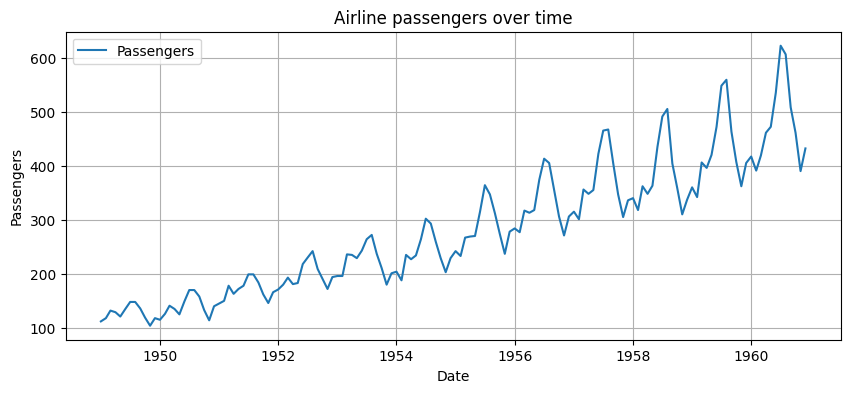

In [3]:
# Visualisation
plt.figure(figsize=(10,4))
plt.plot(df.index, df['Passengers'], label='Passengers')
plt.title('Airline passengers over time')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.grid(True)
plt.legend()
plt.show()


In [4]:
# Prétraitement : log + scaling, création des séquences (sliding window)
series = df['Passengers'].astype(float).values.reshape(-1,1)

# logarithme pour stabiliser variance (optionnel)
use_log = True
if use_log:
    series_proc = np.log(series)
else:
    series_proc = series.copy()

scaler = MinMaxScaler(feature_range=(0,1))
series_scaled = scaler.fit_transform(series_proc)

# paramètres
T = 12   # fenêtre d'entrée (12 mois)
train_size = int(len(series_scaled) * 0.8)

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(series_scaled, T)
X_train, y_train = X[:train_size-T], y[:train_size-T]
X_val, y_val = X[train_size-T:], y[train_size-T:]

print('X_train.shape, y_train.shape:', X_train.shape, y_train.shape)
print('X_val.shape, y_val.shape:', X_val.shape, y_val.shape)


X_train.shape, y_train.shape: (103, 12, 1) (103, 1)
X_val.shape, y_val.shape: (29, 12, 1) (29, 1)


In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # X: (N, T, 1)
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16, shuffle=False)

# Modèle LSTM simple
class LSTMForecaster(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # dernière sortie
        out = self.fc(out)
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LSTMForecaster(input_size=1, hidden_size=64, num_layers=2).to(device)
print(model)


LSTMForecaster(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [6]:
# Entraînement
loss_fn = nn.MSELoss()
opt = torch.optim.Adam(model.parameters(), lr=0.001)
n_epochs = 300

train_losses = []
val_losses = []

for epoch in range(1, n_epochs+1):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        opt.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            preds = model(xb)
            val_loss += loss_fn(preds, yb).item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    if epoch % 50 == 0 or epoch == 1:
        print(f'Epoch {epoch}/{n_epochs} — train_loss: {epoch_loss:.6f}, val_loss: {val_loss:.6f}')


Epoch 1/300 — train_loss: 0.194071, val_loss: 0.369805
Epoch 50/300 — train_loss: 0.006119, val_loss: 0.008947
Epoch 100/300 — train_loss: 0.004447, val_loss: 0.008591
Epoch 150/300 — train_loss: 0.003761, val_loss: 0.004955
Epoch 200/300 — train_loss: 0.002885, val_loss: 0.003177
Epoch 250/300 — train_loss: 0.002266, val_loss: 0.002528
Epoch 300/300 — train_loss: 0.001517, val_loss: 0.002010


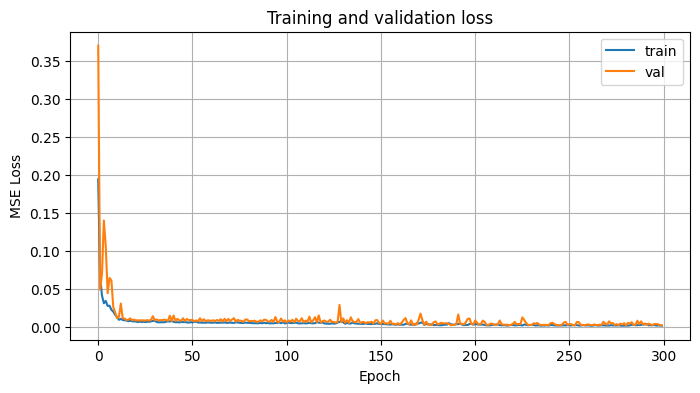

In [7]:
# Tracer les pertes
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('Training and validation loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


RMSE (reconstructed predictions): 21.981921822242263


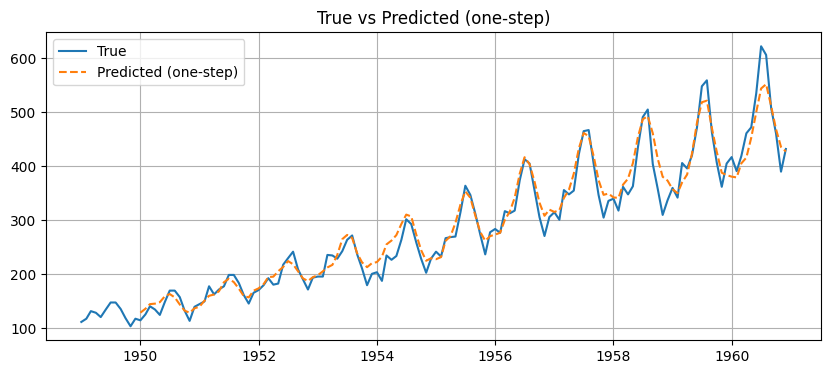

In [8]:
# Prédictions sur l'ensemble (reconstruction pas-à-pas)
model.eval()
all_preds = []

# Nous prédisons one-step-ahead across the sequence portion (for visualization)
with torch.no_grad():
    for i in range(len(X)):
        xi = torch.from_numpy(X[i:i+1]).float().to(device)
        p = model(xi).cpu().numpy()
        all_preds.append(p.ravel()[0])

all_preds = np.array(all_preds).reshape(-1,1)

# Les premières T points n'ont pas de prédiction (sliding window)
pred_series = np.empty((len(series_scaled),1))*np.nan
pred_series[T:] = all_preds

# inverse scaling and inverse log if nécessaire
inv_pred = scaler.inverse_transform(pred_series.copy())
if use_log:
    inv_pred = np.exp(inv_pred)

# vraie série inverse transformée
true_series = series.copy()
if use_log:
    true_series = np.exp(series_proc)

# découpage pour RMSE (on ignore les premiers T where pred is NaN)
mask = ~np.isnan(inv_pred).ravel()
rmse = math.sqrt(mean_squared_error(true_series[mask], inv_pred[mask]))
print('RMSE (reconstructed predictions):', rmse)

# Plot
plt.figure(figsize=(10,4))
plt.plot(df.index, true_series, label='True')
plt.plot(df.index, inv_pred, label='Predicted (one-step)', linestyle='--')
plt.title('True vs Predicted (one-step)')
plt.legend()
plt.grid(True)
plt.show()


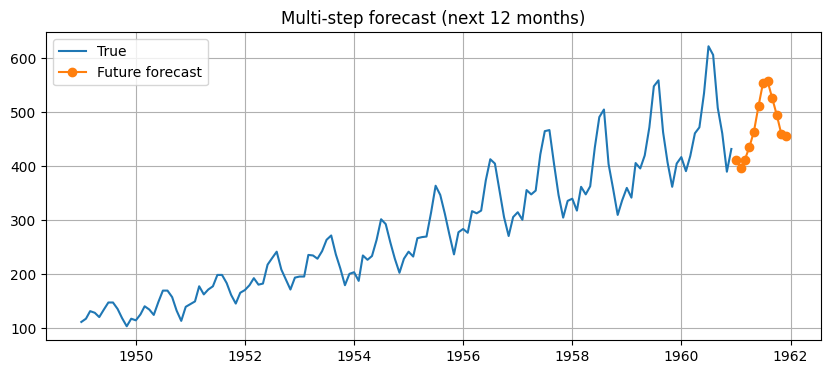

In [9]:
# Exemple de forecast multi-step : prédire les prochains 12 mois
h = 12
last_window = series_scaled[-T:].reshape(1, T, 1)
preds_ms = []
model.eval()
with torch.no_grad():
    cur = last_window.copy()
    for i in range(h):
        xin = torch.from_numpy(cur).float().to(device)
        p = model(xin).cpu().numpy().ravel()[0]
        preds_ms.append(p)
        # shift window and append p
        cur = np.concatenate([cur[:,1:,:], p.reshape(1,1,1)], axis=1)

preds_ms = np.array(preds_ms).reshape(-1,1)
inv_preds_ms = scaler.inverse_transform(preds_ms)
if use_log:
    inv_preds_ms = np.exp(inv_preds_ms)

future_dates = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=h, freq='MS')
plt.figure(figsize=(10,4))
plt.plot(df.index, true_series, label='True')
plt.plot(future_dates, inv_preds_ms, label='Future forecast', marker='o')
plt.title('Multi-step forecast (next 12 months)')
plt.legend()
plt.grid(True)
plt.show()


In [10]:
# Sauvegarde du modèle PyTorch
torch.save(model.state_dict(), 'lstm_airline_pytorch.pt')
print('Modèle sauvegardé dans lstm_airline_pytorch.pt')

Modèle sauvegardé dans lstm_airline_pytorch.pt
